### 1. CORE RMIST-NET

In [1]:
"""
Differential Imaging Attack (DIA) on RMIST-Net

This script:
  1) Rebuilds RMIST-Net and loads trained weights.
  2) Loads real SAR data, precomputed attack pool D, and RM kernels.
  3) Sets up a differentiable RMA imaging layer in PyTorch.
  4) Reparameterizes the complex gain vector A via latent variables Z.
  5) Optimizes A so that RMIST-Net’s output magnitude matches a desired
     camouflaged template (desired_attacked).
  6) Reports image-space and RMIST-level metrics and visualizes results.
"""

import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# ---------------------------------------------------------------------
# 0. Device
# ---------------------------------------------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

from google.colab import drive
drive.mount('/content/drive')

Using device: cuda
Mounted at /content/drive


In [2]:
# ---------------------------------------------------------------------
# 1. RM kernels and RMIST-Net definition
# ---------------------------------------------------------------------
def make_rm_kernels(H, W, R, fc=78.3e9, c=3e8, device='cpu'):
    """
    Build RM forward and adjoint kernels φ_r and φ_r^† on (kx, kz) grid.

      S = RM(α)   = IFFT2( FFT2(α) * φ_r )
      α = RM^†(S) = IFFT2( FFT2(S) * φ_r^† )

    H, W : image size (rows=z, cols=x)
    R    : range slice (scalar)
    """
    # Image-domain coordinates (relative units)
    x = torch.linspace(-W/2, W/2, W, device=device)
    z = torch.linspace(-H/2, H/2, H, device=device)
    dx = x[1] - x[0]
    dz = z[1] - z[0]

    # Spatial frequency sampling
    dkx = 2 * math.pi / (W * dx)
    dkz = 2 * math.pi / (H * dz)
    kx = torch.linspace(-W/2, W/2, W, device=device) * dkx
    kz = torch.linspace(-H/2, H/2, H, device=device) * dkz

    # Meshgrid (Kx, Kz)
    Kx, Kz = torch.meshgrid(kx, kz, indexing='xy')
    K0 = 2 * math.pi * fc / c
    K_sq = Kx**2 + Kz**2
    K_check = 4 * (K0**2) - K_sq
    Ky = torch.sqrt(torch.clamp(K_check, min=0.0))

    # Forward kernel φ_r
    Ky_safe = torch.where(Ky == 0, torch.ones_like(Ky), Ky)
    phi = (1.0 / Ky_safe) * torch.exp(-1j * Ky * R)
    phi = torch.where(Ky == 0, torch.zeros_like(phi), phi)

    # Adjoint kernel φ_r^†
    phi_dag = Ky * torch.exp(1j * Ky * R)

    return phi, phi_dag  # each (W, H) complex


def rm_forward(alpha_ri, phi):
    """
    RM forward: S = RM(α)

    alpha_ri : (B, 2, H, W) [Re, Im]
    phi      : (W, H) complex kernel φ_r
    returns  : (B, 2, H, W) [Re, Im]
    """
    B, _, H, W = alpha_ri.shape
    alpha = torch.complex(alpha_ri[:, 0], alpha_ri[:, 1])  # (B,H,W)
    F_alpha = torch.fft.fft2(alpha)

    # Ensure phi is (H, W)
    if phi.shape[0] == W and phi.shape[1] == H:
        phi_hw = phi.permute(1, 0)
    else:
        phi_hw = phi

    S = F_alpha * phi_hw
    s = torch.fft.ifft2(S)
    return torch.stack([s.real, s.imag], dim=1)


def rm_adjoint(s_ri, phi_dag):
    """
    RM adjoint: α = RM^†(S)

    s_ri    : (B, 2, H, W) [Re, Im]
    phi_dag : (W, H) complex kernel φ_r^†
    returns : (B, 2, H, W) [Re, Im]
    """
    B, _, H, W = s_ri.shape
    s = torch.complex(s_ri[:, 0], s_ri[:, 1])
    F_s = torch.fft.fft2(s)

    if phi_dag.shape[0] == W and phi_dag.shape[1] == H:
        phi_dag_hw = phi_dag.permute(1, 0)
    else:
        phi_dag_hw = phi_dag

    A = F_s * phi_dag_hw
    a = torch.fft.ifft2(A)
    return torch.stack([a.real, a.imag], dim=1)


class RMISTPhase(nn.Module):
    """
    One unrolled ISTA phase:

        v_t      = S - RM(α_t)
        r_t      = α_t + τ_t * RM^†(v_t)
        α_{t+1}  = F_st(r_t, θ_t)

    with complex soft-thresholding F_st.
    """
    def __init__(self, phi, phi_dag):
        super().__init__()
        # Fixed physics kernels
        self.register_buffer('phi', phi)
        self.register_buffer('phi_dag', phi_dag)
        # Trainable scalars τ_t, θ_t
        self.tau = nn.Parameter(torch.tensor(1e-4, dtype=torch.float32))
        self.theta = nn.Parameter(torch.tensor(1e-3, dtype=torch.float32))

    def soft_thresh(self, r):
        """
        Complex soft thresholding:
          α_next = r * max(|r| - θ, 0) / |r|
        r : (B, 2, H, W) [Re, Im]
        """
        real = r[:, 0]
        imag = r[:, 1]
        mag  = torch.sqrt(real**2 + imag**2 + 1e-12)
        shr  = torch.relu(mag - self.theta)   # max(|r|-θ, 0)
        scale = shr / (mag + 1e-12)
        real2 = real * scale
        imag2 = imag * scale
        return torch.stack([real2, imag2], dim=1)

    def forward(self, S_ri, alpha_ri):
        # Stage 1: residual v_t = S - RM(α_t)
        RM_alpha = rm_forward(alpha_ri, self.phi)
        v = S_ri - RM_alpha

        # Stage 2: gradient step r_t = α_t + τ_t * RM^†(v_t)
        grad = rm_adjoint(v, self.phi_dag)
        r = alpha_ri + self.tau * grad

        # Stage 3: shrinkage α_{t+1} = F_st(r_t, θ_t)
        alpha_next = self.soft_thresh(r)
        return alpha_next


class RMISTNet(nn.Module):
    """
    RMIST-Net: T-phase unrolled RM + ISTA sparse reconstruction network.
    """
    def __init__(self, H, W, R, fc=78.3e9, c=3e8, T=6, device='cpu'):
        super().__init__()
        phi, phi_dag = make_rm_kernels(H, W, R, fc, c, device=device)
        self.phases = nn.ModuleList([RMISTPhase(phi, phi_dag) for _ in range(T)])

    def forward(self, S_ri):
        # Initialization: α_0 = RM^†(S)
        alpha = rm_adjoint(S_ri, self.phases[0].phi_dag)
        # Unroll T ISTA phases
        for phase in self.phases:
            alpha = phase(S_ri, alpha)
        return alpha

### (2). DIFFERENTIAL IMAGING ATTACK ON RMIST

In [3]:
# ---------------------------------------------------------------------
# 2. Load data and constants
# ---------------------------------------------------------------------
data_path = '/content/drive/MyDrive/Colab Notebooks/RMIST_Net/'

rawSAR          = loadmat(os.path.join(data_path, 'rawSAR.mat'))['adcDataCube']  # (Nsamp, M, N)
D               = loadmat(os.path.join(data_path, 'D.mat'))['D']                 # (Nsamp, M*N)
trueImage_cmplx = loadmat(os.path.join(data_path, 'trueImage_complex_RMA_RMIST_512.mat'))['trueImage_complex']
desired_attacked = loadmat(os.path.join(data_path, 'desired_attacked_complex_RMA_RMIST.mat'))['sar_camouflaged']
Phi_r_dag       = loadmat(os.path.join(data_path, 'Phi_r_dag.mat'))['Phi_r_dag']
global_max_mat  = loadmat(os.path.join(data_path, 'global_max.mat'))['global_max']

S_hat_knife  = loadmat(os.path.join(data_path, 'S_hat_knife.mat'))['S_hat']

global_max = float(np.array(global_max_mat).squeeze())
print("global_max used for RMIST normalization:", global_max)

# -------------------------
# 2) Define S_clean (clean S_hat)
# -------------------------
# F_A = fft2(alpha_true)
#F_true = np.fft.fft2(S_hat_knife)

# S_temp = F_A .* Phi_r_dag
#S_temp = F_true * Phi_r_dag

# S_hat_clean = ifft2(S_temp) / global_max
#S_clean = np.fft.ifft2(S_temp) / (global_max + 1e-12)   # (H, W) complex
S_clean = S_hat_knife /(global_max + 1e-12)

print("S_clean shape:", S_clean.shape, "dtype:", S_clean.dtype)

print("rawSAR:", rawSAR.shape)
print("D:", D.shape)
print("trueImage_complex:", trueImage_cmplx.shape)
print("desired_attacked:", desired_attacked.shape)
print("Phi_r_dag:", Phi_r_dag.shape)


global_max used for RMIST normalization: 1.0000001192092896
S_clean shape: (512, 512) dtype: complex128
rawSAR: (256, 200, 200)
D: (256, 40000)
trueImage_complex: (512, 512)
desired_attacked: (512, 512)
Phi_r_dag: (512, 512)


In [6]:
# ---------------------------------------------------------------------
# 3. Rebuild and load RMIST-Net
# ---------------------------------------------------------------------
H, W = trueImage_cmplx.shape       # 512 x 512
R_mat = 0.185                      # use your actual R
T_phases = 9                       # same as training

model = RMISTNet(H, W, R=R_mat, device=device, T=T_phases).to(device)
state_dict = torch.load(
    os.path.join(data_path, 'trained_model', 'RMISTNet_weights.pth'),
    map_location=device
)
model.load_state_dict(state_dict)
model.eval()
print("Loaded RMIST-Net weights.")

Loaded RMIST-Net weights.


In [7]:
# ---------------------------------------------------------------------
# 4. Torch RMA + RMIST interface helpers
# ---------------------------------------------------------------------
c0 = 3e8
F0 = 77e9
FS = 5_000_000.0
Ts = 1.0 / FS
K0 = 70.295e12
tI = 4.5225e-10

Nsamp, M, N = rawSAR.shape
Np = M * N

nFFTtime  = Nsamp     # 256
nFFTspace = 512
ID_select = 6
k0_range_bin = ID_select - 1  # 0-based index


def rma_torch_from_sarData_torch(sarData_torch, params_torch):
    """
    Torch version of 2D RMA so gradients flow through A.

    sarData_torch : (M, N) complex
    returns       : (img_mag_norm, img_complex) with size (nFFTspace, nFFTspace)
    """
    nFFTspace = params_torch['nFFTspace']
    dx        = params_torch['dx']
    dy        = params_torch['dy']
    F0        = params_torch['F0']
    z0        = params_torch['z0']

    c = 3e8
    k = 2 * np.pi * F0 / c

    Mloc, Nloc = sarData_torch.shape
    pad_x = nFFTspace - Nloc
    pad_y = nFFTspace - Mloc

    pad_x_pre  = pad_x // 2
    pad_x_post = pad_x - pad_x_pre
    pad_y_pre  = pad_y // 2
    pad_y_post = pad_y - pad_y_pre

    # Pad to (nFFTspace, nFFTspace)
    sarData_padded = F.pad(
        sarData_torch.unsqueeze(0).unsqueeze(0),
        (pad_x_pre, pad_x_post, pad_y_pre, pad_y_post)
    )[0, 0, :, :]

    # Build kX, kY grids
    wSx = 2 * np.pi / (dx * 1e-3)
    wSy = 2 * np.pi / (dy * 1e-3)
    kX = np.linspace(-wSx/2, wSx/2, nFFTspace)
    kY = np.linspace(-wSy/2, wSy/2, nFFTspace)
    KX_np, KY_np = np.meshgrid(kX, kY)

    KX_t = torch.tensor(KX_np, dtype=torch.float32, device=device)
    KY_t = torch.tensor(KY_np, dtype=torch.float32, device=device)

    K2 = (2*k)**2 - (KX_t**2 + KY_t**2)
    K2 = torch.clamp(K2, min=0.0)
    Kz = torch.sqrt(K2)

    phaseFactor0 = torch.exp(-1j * z0 * Kz)
    evanescent_mask = (KX_t**2 + KY_t**2) > (2*k)**2
    phaseFactor0[evanescent_mask] = 0.0 + 0.0j

    phaseFactor = Kz * phaseFactor0
    phaseFactor = torch.fft.fftshift(torch.fft.fftshift(phaseFactor, dim=0), dim=1)

    sarFFT   = torch.fft.fft2(sarData_padded)
    img_full = torch.fft.ifft2(sarFFT * phaseFactor)
    img_full_shifted = torch.fft.fftshift(img_full, dim=(0, 1))

    # Auto-center brightest pixel
    mag_tmp = torch.abs(img_full_shifted)
    idx_max = torch.argmax(mag_tmp)
    i_max = int(idx_max // mag_tmp.shape[1])
    j_max = int(idx_max %  mag_tmp.shape[1])
    center = (nFFTspace - 1) / 2.0
    shift_y = int(round(center - i_max))
    shift_x = int(round(center - j_max))

    img_centered = torch.roll(torch.roll(img_full_shifted, shift_y, 0), shift_x, 1)

    img_mag = torch.abs(img_centered)
    rms_val = torch.sqrt(torch.mean(img_mag**2) + 1e-12)
    img_norm = img_mag / rms_val

    return img_norm, img_centered


def form_S_hat_from_alpha_torch(alpha_complex_torch, Phi_r_dag_torch, global_max):
    """
    S_hat = RM(α) in frequency domain:

        F_A   = fft2(α)
        S_tmp = F_A * Phi_r_dag
        S_hat = ifft2(S_tmp) / global_max
    """
    F_A   = torch.fft.fft2(alpha_complex_torch)
    S_tmp = F_A * Phi_r_dag_torch
    S_hat = torch.fft.ifft2(S_tmp)
    S_hat_norm = S_hat / (global_max + 1e-12)
    return S_hat_norm


def make_target_mag_torch(desired_attacked_np):
    """
    Build target magnitude image (RMS-normalized) from desired_attacked.
    """
    mag = np.abs(desired_attacked_np)
    rms = np.sqrt(np.mean(mag**2) + 1e-12)
    targ = mag / rms
    t = torch.tensor(targ, dtype=torch.float32, device=device)
    return t.unsqueeze(0).unsqueeze(0)   # (1,1,H,W)


In [8]:
# ---------------------------------------------------------------------
# 5. Prepare tensors and params
# ---------------------------------------------------------------------
X_v = rawSAR.reshape(Nsamp, Np).astype(np.complex64)  # (Nsamp, Np)
D   = D.astype(np.complex64)

X_v_t       = torch.tensor(X_v, dtype=torch.complex64, device=device)
D_t         = torch.tensor(D, dtype=torch.complex64, device=device)
Phi_r_dag_t = torch.tensor(Phi_r_dag.astype(np.complex64),
                           dtype=torch.complex64, device=device)
assert Phi_r_dag_t.shape == (H, W), \
    f"Phi_r_dag shape {Phi_r_dag_t.shape} != {(H, W)}"

target_mag_torch = make_target_mag_torch(desired_attacked).to(device)

params_torch = {
    'nFFTspace': nFFTspace,
    'dx': 1.0,
    'dy': 1.0,
    'F0': F0,
    'z0': c0/2.0 * ((ID_select) / (K0 * (1/FS) * nFFTtime) - tI)
}


In [9]:
# ---------------------------------------------------------------------
# 6. Reparameterized A via latent Z
# ---------------------------------------------------------------------
def get_A_from_Z(Z_re, Z_im, Amax=2.0):
    """
    Smooth parameterization:

        A_re = (Amax / sqrt(2)) * tanh(Z_re)
        A_im = (Amax / sqrt(2)) * tanh(Z_im)

    so each component lies in [-Amax/sqrt(2), Amax/sqrt(2)],
    guaranteeing |A_k| <= Amax without any hard projection.
    """
    scale = Amax / math.sqrt(2.0)
    A_re = scale * torch.tanh(Z_re)
    A_im = scale * torch.tanh(Z_im)
    return A_re, A_im


Amax       = 2.0      # physical bound on |A_k|
lambda_A   = 1e-4     # L2 reg on A
num_iters  = 1000
lr_high    = 1e-1
lr_low     = 1e-3
lr_switch_iter = 100

# Latent variables Z (unbounded); A comes from tanh(Z)
Z_re = torch.nn.Parameter(1e-3 * torch.randn(Np, device=device))
Z_im = torch.nn.Parameter(1e-3 * torch.randn(Np, device=device))

optimizer = torch.optim.Adam([Z_re, Z_im], lr=lr_high)

print("Starting reparameterized optimization over A (via Z)...")

for it in range(1, num_iters + 1):
    # Simple LR schedule
    if it == lr_switch_iter + 1:
        for g in optimizer.param_groups:
            g["lr"] = lr_low
        print(f"[LR] switched Adam lr from {lr_high} to {lr_low}")

    optimizer.zero_grad()

    # 1) Get bounded A from Z
    A_re_cur, A_im_cur = get_A_from_Z(Z_re, Z_im, Amax=Amax)  # (Np,)
    A_complex = A_re_cur + 1j * A_im_cur                      # (Np,)

    # 2) Inject attack: Y = X_v + D .* A^T
    Y_t = X_v_t + D_t * A_complex.unsqueeze(0)                # (Nsamp, Np)

    # 3) Reshape -> Echo and range FFT
    Y_cube = Y_t.reshape(Nsamp, M, N)                         # (Nsamp, M, N)
    Echo   = torch.permute(Y_cube, (2, 1, 0))                 # (N, M, Nsamp)
    rawDataFFT = torch.fft.fft(Echo, n=nFFTtime, dim=2)
    sar_slice  = rawDataFFT[:, :, k0_range_bin]               # (N, M)
    sarData    = sar_slice.permute(1, 0)                      # (M, N)

    # 4) Serpentine flip every other row
    Mloc, Nloc = sarData.shape
    for rr in range(1, Mloc, 2):  # 1,3,5,... (0-based)
        sarData[rr, :] = torch.flip(sarData[rr, :], dims=[0])

    # 5) RMA imaging -> α_att
    atk_mag_norm_t, atk_image_complex_t = rma_torch_from_sarData_torch(
        sarData, params_torch
    )

    # Crop to (H, W) if needed
    if atk_image_complex_t.shape != (H, W):
        ph = (atk_image_complex_t.shape[0] - H)//2
        pw = (atk_image_complex_t.shape[1] - W)//2
        atk_image_complex_crop = atk_image_complex_t[ph:ph+H, pw:pw+W]
    else:
        atk_image_complex_crop = atk_image_complex_t

    # 6) Range-migration back to echo domain: S_hat
    S_hat_t = form_S_hat_from_alpha_torch(
        atk_image_complex_crop, Phi_r_dag_t, global_max
    )

    # 7) Feed into RMIST-Net
    S_hat_ri = torch.stack(
        [S_hat_t.real, S_hat_t.imag], dim=0
    ).unsqueeze(0)                                     # (1,2,H,W)
    S_hat_ri = S_hat_ri.to(torch.float32).to(device)

    alpha_pred_ri = model(S_hat_ri)                    # (1,2,H,W)

    # 8) Magnitude, RMS-normalize (same as training)
    mag_pred = torch.sqrt(
        alpha_pred_ri[:, 0, :, :]**2 +
        alpha_pred_ri[:, 1, :, :]**2 + 1e-12
    )
    mag_pred = mag_pred.unsqueeze(1)                   # (1,1,H,W)
    rms_mag  = torch.sqrt(torch.mean(mag_pred**2) + 1e-12)
    mag_norm = mag_pred / rms_mag                      # (1,1,H,W)

    # 9) Loss: image match + power regularization on A
    loss_img = torch.mean((mag_norm - target_mag_torch)**2)
    power_A  = torch.mean(A_re_cur**2 + A_im_cur**2)
    loss_reg = lambda_A * power_A
    loss     = loss_img + loss_reg

    loss.backward()
    optimizer.step()

    if it == 1 or it % 10 == 0 or it == num_iters:
        with torch.no_grad():
            meanA = torch.mean(torch.abs(A_complex)).item()
            maxA  = torch.max(torch.abs(A_complex)).item()
        print(
            f"[{it:03d}/{num_iters:03d}] "
            f"loss={loss.item():.4e}, img={loss_img.item():.4e}, "
            f"power={power_A.item():.4e}, mean|A|={meanA:.3e}, max|A|={maxA:.3e}"
        )

print("Reparameterized attack optimization finished.")


Starting reparameterized optimization over A (via Z)...
[001/1000] loss=1.6554e+00, img=1.6554e+00, power=4.0228e-06, mean|A|=1.780e-03, max|A|=6.750e-03
[010/1000] loss=6.3277e-01, img=6.3264e-01, power=1.2556e+00, mean|A|=1.093e+00, max|A|=1.423e+00
[020/1000] loss=5.0797e-01, img=5.0775e-01, power=2.1588e+00, mean|A|=1.437e+00, max|A|=1.876e+00
[030/1000] loss=4.5501e-01, img=4.5477e-01, power=2.4707e+00, mean|A|=1.542e+00, max|A|=1.951e+00
[040/1000] loss=4.0923e-01, img=4.0896e-01, power=2.6204e+00, mean|A|=1.591e+00, max|A|=1.970e+00
[050/1000] loss=4.3659e-01, img=4.3632e-01, power=2.7037e+00, mean|A|=1.617e+00, max|A|=1.976e+00
[060/1000] loss=4.2241e-01, img=4.2213e-01, power=2.7659e+00, mean|A|=1.637e+00, max|A|=1.980e+00
[070/1000] loss=4.3083e-01, img=4.3054e-01, power=2.8296e+00, mean|A|=1.658e+00, max|A|=1.983e+00
[080/1000] loss=3.7567e-01, img=3.7539e-01, power=2.8816e+00, mean|A|=1.675e+00, max|A|=1.985e+00
[090/1000] loss=4.0961e-01, img=4.0931e-01, power=2.9292e+00, 

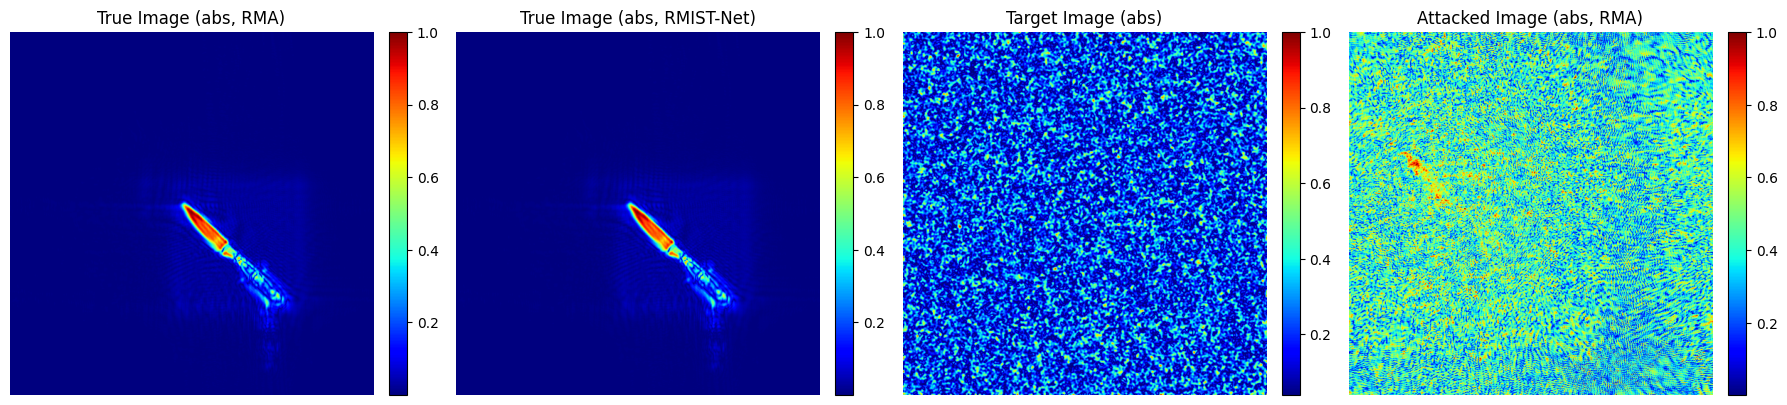


Final image-domain metrics vs desired_attacked:
  MSE : 7.355792e-02
  NCC : 0.8088


"\n# 7.3 Magnitude images (physics + RMIST + target)\nI_true_phys = np.abs(trueImage_cmplx)    # physics clean (RMA)\nI_true_rmst = I_true_rmist               # RMIST clean\nI_att       = np.abs(atk_img_np)         # physics attacked\nI_tgt       = np.abs(desired_attacked)   # desired target template\n\n# ---- common amplitude range for all panels ----\nvmin = 0.0\nvmax = max(I_true_phys.max(),\n           I_true_rmst.max(),\n           I_att.max(),\n           I_tgt.max()) + 1e-12\n\nplt.figure(figsize=(18, 4))\n\nplt.subplot(1, 4, 1)\nplt.imshow(I_true_phys, cmap='jet', origin='lower',\n           vmin=vmin, vmax=vmax)\nplt.title('True Image (abs, RMA)')\nplt.colorbar(fraction=0.046, pad=0.04)\nplt.axis('off')\n\nplt.subplot(1, 4, 2)\nplt.imshow(I_true_rmst, cmap='jet', origin='lower',\n           vmin=vmin, vmax=vmax)\nplt.title('True Image (abs, RMIST)')\nplt.colorbar(fraction=0.046, pad=0.04)\nplt.axis('off')\n\nplt.subplot(1, 4, 3)\nplt.imshow(I_tgt, cmap='jet', origin='lower',\n

In [15]:
# ---------------------------------------------------------------------
# 7. Final attacked image: abs-only plots and image-domain metrics
# ---------------------------------------------------------------------
model.eval()

# 7.1 RMIST clean reconstruction (true image from RMIST-Net)
with torch.no_grad():
    # S_clean is your normalized clean Ŝ from S_hat_knife.mat (H×W complex)
    S_hat_clean = torch.tensor(S_clean,
                               device=device,
                               dtype=torch.complex64)

    # Pack as (1, 2, H, W) real/imag channels for RMIST-Net
    S_hat_clean_ri = torch.stack(
        [S_hat_clean.real, S_hat_clean.imag], dim=0
    ).unsqueeze(0)                      # (1,2,H,W)
    S_hat_clean_ri = S_hat_clean_ri.to(torch.float32)

    # Forward through RMIST-Net
    alpha_clean_ri = model(S_hat_clean_ri)           # (1,2,H,W)

    # Magnitude, RMS-normalized (same style as training)
    mag_clean = torch.sqrt(
        alpha_clean_ri[:, 0, :, :]**2 +
        alpha_clean_ri[:, 1, :, :]**2 + 1e-12
    )                                                # (1,H,W)
    mag_clean = mag_clean.unsqueeze(1)               # (1,1,H,W)
    rms_clean = torch.sqrt(torch.mean(mag_clean**2) + 1e-12)
    mag_clean_norm = (mag_clean / rms_clean)[0, 0]   # (H,W)

    # RMIST clean |α|
    I_true_rmist = mag_clean_norm.cpu().numpy()

# 7.2 Final attacked physics image via RMA
with torch.no_grad():
    A_re_final, A_im_final = get_A_from_Z(Z_re, Z_im, Amax=Amax)
    A_complex_final = A_re_final + 1j * A_im_final          # (Np,)

    Y_t    = X_v_t + D_t * A_complex_final.unsqueeze(0)     # (Nsamp,Np)
    Y_cube = Y_t.reshape(Nsamp, M, N)                       # (Nsamp,M,N)
    Echo   = torch.permute(Y_cube, (2, 1, 0))               # (N,M,Nsamp)

    rawDataFFT = torch.fft.fft(Echo, n=nFFTtime, dim=2)
    sar_slice  = rawDataFFT[:, :, k0_range_bin]             # (N,M)
    sarData    = sar_slice.permute(1, 0)                    # (M,N)

    # Serpentine correction
    for rr in range(1, sarData.shape[0], 2):
        sarData[rr, :] = torch.flip(sarData[rr, :], dims=[0])

    atk_mag_norm_t, atk_image_complex_t = rma_torch_from_sarData_torch(
        sarData, params_torch
    )

    # Crop to (H,W) if needed
    if atk_image_complex_t.shape != (H, W):
        ph = (atk_image_complex_t.shape[0] - H) // 2
        pw = (atk_image_complex_t.shape[1] - W) // 2
        atk_image_complex_crop = atk_image_complex_t[ph:ph+H, pw:pw+W]
    else:
        atk_image_complex_crop = atk_image_complex_t

    atk_img_np = atk_image_complex_crop.cpu().numpy()

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 7. Final visualization + image-domain metrics
# --------------------------------------------------

# 7.1 Magnitude images from complex fields
I_true_phys = np.abs(trueImage_cmplx)     # True physics (RMA) image
I_true_rmst = I_true_rmist               # True RMIST image (already magnitude)
I_tgt       = np.abs(desired_attacked)   # Target template
I_att       = np.abs(atk_img_np)         # Final attacked physics image


I_true_phys = I_true_phys/ I_true_phys.max()    # True physics (RMA) image
I_true_rmst = I_true_rmist/I_true_rmist.max()           # True RMIST image (already magnitude)
I_tgt       = I_tgt/ I_tgt.max()       # Target template
I_att       = I_att/ I_att.max()         # Final attacked physics image


# 7.2 Put all four on the SAME dynamic range
vmax = max(I_true_phys.max(),
           I_true_rmst.max(),
           I_tgt.max(),
           I_att.max()) + 1e-12
vmin = 0.0

plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
plt.imshow(I_true_phys, cmap='jet', origin='lower')
plt.title('True Image (abs, RMA)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(I_true_rmst, cmap='jet', origin='lower')
plt.title('True Image (abs, RMIST-Net)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(I_tgt, cmap='jet', origin='lower')
plt.title('Target Image (abs)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(I_att, cmap='jet', origin='lower')
plt.title('Attacked Image (abs, RMA)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()

# 7.3 Metrics vs desired target (physics space)
mse_val = np.mean((I_att - I_tgt) ** 2)
ncc_val = np.sum(I_att.flatten() * I_tgt.flatten()) / (
    np.sqrt(np.sum(I_att**2)) * np.sqrt(np.sum(I_tgt**2)) + 1e-12
)

print("\nFinal image-domain metrics vs desired_attacked:")
print(f"  MSE : {mse_val:.6e}")
print(f"  NCC : {ncc_val:.4f}")

In [16]:
# ---------------------------------------------------------------------
# 8. RMIST-level attack metrics (network output magnitude)
# ---------------------------------------------------------------------
att = mag_norm[0, 0].detach().cpu().numpy().astype(np.float32)       # (H, W)
tgt = target_mag_torch[0, 0].detach().cpu().numpy().astype(np.float32)

mse_val  = np.mean((att - tgt) ** 2)
rmse_val = np.sqrt(mse_val)
mae_val  = np.mean(np.abs(att - tgt))

num = np.sum(att * tgt)
den = np.sqrt(np.sum(att**2) * np.sum(tgt**2)) + 1e-12
ncc_val = num / den

data_range = float(tgt.max() - tgt.min() + 1e-12)
ssim_val   = ssim(tgt, att, data_range=data_range)
psnr_val   = psnr(tgt, att, data_range=data_range)

print("\n--- RMIST-level attack metrics ---")
print(f"MSE   : {mse_val:.4e}")
print(f"RMSE  : {rmse_val:.4e}")
print(f"MAE   : {mae_val:.4e}")
print(f"NCC   : {ncc_val:.4f}")
print(f"SSIM  : {ssim_val:.4f}")
print(f"PSNR  : {psnr_val:.2f} dB")


--- RMIST-level attack metrics ---
MSE   : 3.8231e-01
RMSE  : 6.1831e-01
MAE   : 5.0300e-01
NCC   : 0.8088
SSIM  : 0.0853
PSNR  : 15.77 dB
